In [430]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [431]:
dev = pd.read_csv("../data/casas_dev.csv")

1.1

Fragmento random del dataset

In [432]:
dev.sample(5)

,precio,tipo,Área,metros_cubiertos,unidades,ambientes,pisos,pileta,lat,lon,edad
565,12060.435205,casa,232.378912,159.732461,m2,7,3.0,False,-34.806207,-58.313883,26.570162
551,30427.070160,casa,259.951230,195.340780,m2,10,3.0,False,-34.836969,-58.263180,58.323425
1371,132042.976897,depto,742.255147,717.572623,sqft,10,NaN,False,40.689772,-74.028430,NaN
848,25070.288215,casa,213.982124,165.219862,m2,10,3.0,False,-34.706360,-58.241088,28.961614
1217,0.000000,depto,772.706161,752.542662,sqft,9,NaN,False,40.739252,-73.924276,8.181016


Variables posibles dentro de unidades y tipo

In [433]:
print(dev['tipo'].unique())
print(dev['unidades'].unique())


['depto' 'casa' 'ph']
['sqft' 'm2']


Lo uso porque de esta manera me aseguro que no haya otros valores posibles para luego categorizar.

- Columna unidades: deberia estar en una misma medida, elijo m2
- Columna pisos: demasiados NaN
- Columna pileta: convertir en 1(True) y 0(False)
- Columna tipo: pasar de variable categorica a numero
- Normalizar las variables (las escalas son demasiado distintas)

Busco NaNs en cada columna:

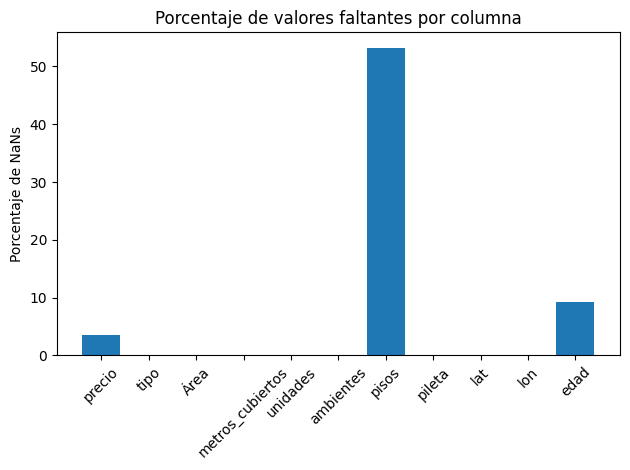

In [434]:
columnas = []
porcentajes = []
for col in dev.columns:
	columna = dev[col]
	total_NaNs_en_columna = columna.isna().sum() #sumo cantidad de NaNs 
	porcentaje_NaNs_en_columna = (total_NaNs_en_columna/dev.shape[0]) * 100

	columnas.append(col)
	porcentajes.append(porcentaje_NaNs_en_columna)

plt.figure()
plt.bar(columnas, porcentajes)
plt.xticks(rotation=45)
plt.ylabel("Porcentaje de NaNs")
plt.title("Porcentaje de valores faltantes por columna")
plt.tight_layout()
plt.show()


Decido eliminar la columna de pisos porque hay mas de un 50% de valores faltantes, lo que puede producir sesgos importantes. 

Las demas no tienen  porcentajes tan significativos 
--> utilizo mediana para estimar valores numericos


Antes de eliminar veo la correlacion de precios con pisos (en los valores que no son NaN), para tomar desicion final

In [435]:
correlacion_pisos_precios = dev['precio'].corr(dev['pisos'])
print(correlacion_pisos_precios)

-0.2330073130026114


Efectivamente es conveniente eliminar la columna de pisos. Ademas de los valores faltantes, la correlacion entre precios y pisos (con los valores que si existe) es muy debil.

In [436]:
dev = dev.drop('pisos', axis=1) #elimina columna pisos

Identico como estan distribuidas las casas en lat y long

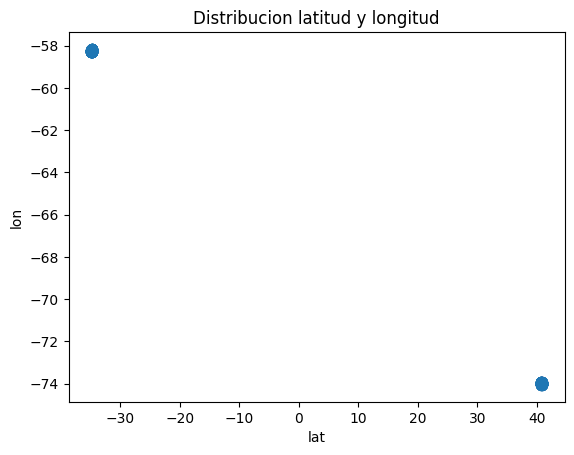

In [437]:
plt.figure()

lat = dev['lat']
lon = dev['lon']
plt.scatter(lat,lon,s=50, alpha=0.3)
plt.xlabel("lat")
plt.ylabel("lon")
plt.title("Distribucion latitud y longitud")

plt.show()

Se puede ver que la ubicacion de las casas (en lat y lon) estan concentradas unicamente en dos lugares:
Mirando el grafico se puede ver que estas son: 1 --> (-34, -58): buscandolo en el mapa equivale a la provincia de Buenos Aires (Argentina) y 2 --> (40,-74): buscandolo en el mapa equivale a New York (USA)

Agrego Feature nueva Ubicacion que reemplaza lat y long. 
Los valores seran 1 si la ubicacion es New York y 0 si es Buenos Aires (para no usar variables categoricas)

In [438]:
dev['Ubicacion'] = (dev['lat'] > 0).astype(int) #crea una columna nueva fijandose por la latitud si es New York o Argentina (solo hace falta ver latitud)

Elimino lat y long porque ubicacion las reemplazo

In [439]:
dev = dev.drop('lat',axis=1)
dev = dev.drop('lon',axis=1)

Cambio columna pileta a 1/0 en vez de True/False

In [440]:
dev['pileta'] = (dev['pileta']).astype(int)

Convierto sqft en m2

Cuando la variable en Area/metros cubiertos este escrita en sqft, la paso a metros

In [441]:
dev.loc[dev['Ubicacion'] == 1, 'Área'] = dev.loc[dev['Ubicacion'] == 1, 'Área'] / 10.764 
dev.loc[dev['Ubicacion'] == 1, 'metros_cubiertos'] = dev.loc[dev['Ubicacion'] == 1, 'metros_cubiertos'] / 10.764 

Ahora elimino la columna unidades porque ya esta unificado en m2

In [442]:
dev = dev.drop('unidades',axis=1)

Analizo rango de precios en Argentina

In [443]:
print(dev.loc[dev['Ubicacion'] == 0, 'precio'].describe())

count       876.000000
mean      23021.185463
std       20631.981961
min           0.000000
25%        4130.007417
50%       20865.868299
75%       35116.067489
max      114468.672042
Name: precio, dtype: float64


Analizo rango de precios en USA

In [444]:
print(dev.loc[dev['Ubicacion'] == 1, 'precio'].describe())

count       669.000000
mean     185425.181596
std       77552.550549
min           0.000000
25%      139937.555600
50%      179347.253703
75%      219477.145996
max      769962.673560
Name: precio, dtype: float64


Tomo en cuenta que hay algo raro en los precios de Argentina

CHECK DE CAMBIOS EN EL DATASET

In [445]:
dev.sample(5)

,precio,tipo,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion
1084,36242.807729,casa,232.177240,95.341283,6,0,71.637622,0
398,69471.587315,casa,255.280278,197.357483,10,0,66.738409,0
1179,0.000000,casa,224.564152,178.149491,10,0,53.979516,0
743,0.000000,casa,224.693763,100.043534,10,0,21.656804,0
1489,73116.565373,casa,185.284088,90.861715,9,0,44.148716,0


Analisis con Boxplot

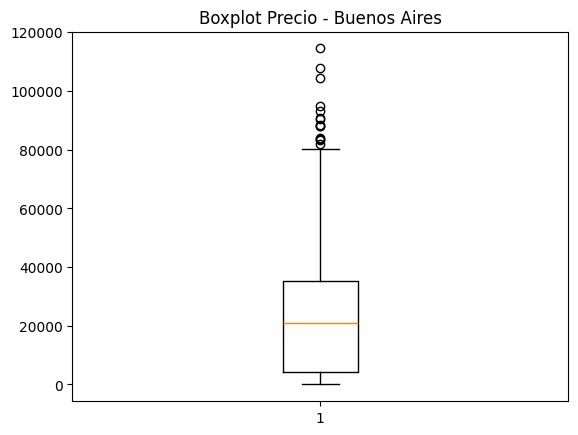

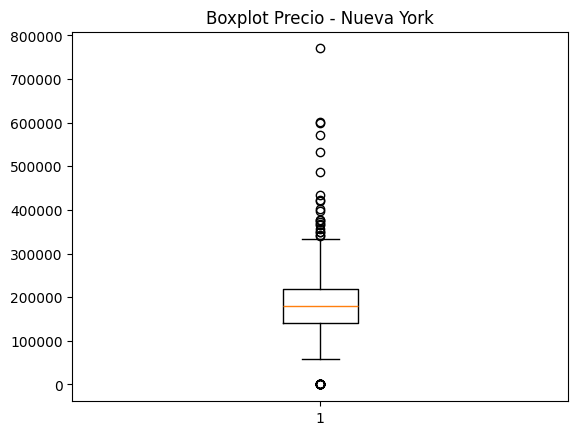

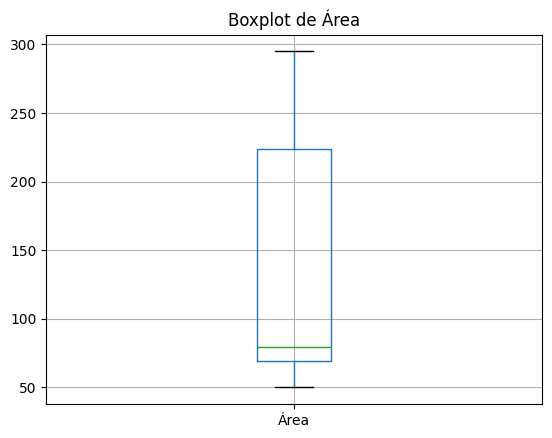

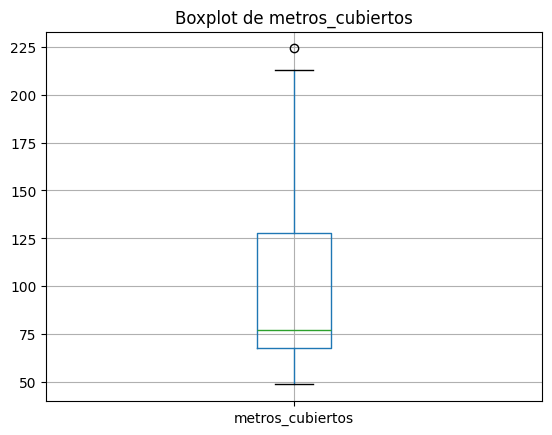

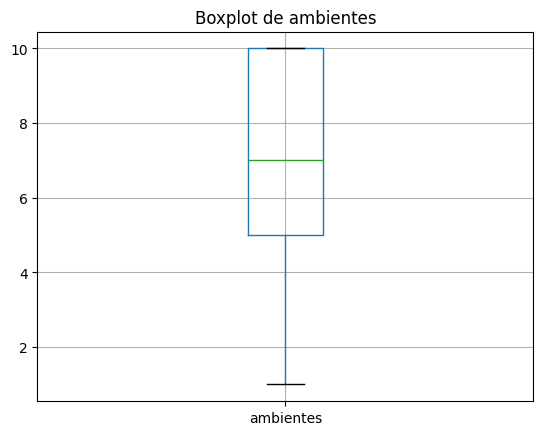

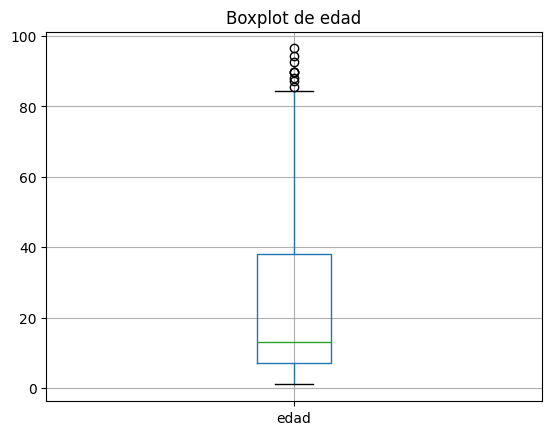

In [458]:
plt.figure()
plt.boxplot(dev.loc[dev['Ubicacion'] == 0, 'precio'].dropna())
plt.title('Boxplot Precio - Buenos Aires')
plt.show()

plt.figure()
plt.boxplot(dev.loc[dev['Ubicacion'] == 1, 'precio'].dropna())
plt.title('Boxplot Precio - Nueva York')
plt.show()
for col in dev.select_dtypes(include=['number']).columns:
	if col != 'precio' and col != 'Ubicacion' and col != 'pileta':
		plt.figure()
		dev.boxplot(column=col)
		plt.title(f'Boxplot de {col}')
		plt.show()

In [457]:
dev['pileta'].value_counts(normalize=True)*100

pileta
0    82.4375
1    17.5625
Name: proportion, dtype: float64

Un 82% de casas no tiene pileta pero hay un 18% que si. La feature puede aportar algo al modelo.

Analisis Boxplots (tomando en cuenta lo importante): 

- Precios: 
Buenos Aires: Concentrados entre 0 y 20000 con outliers arriba de 80000. Sesgo hacia valores altos.
Nueva York: Concentrados entre 100000 y 250000 con outliers arriba de 400000 y cercanos a 0.

- Area:
Concentrada entre 50 y 200 con outliers arriba de 250.

- Metros Cubiertos:
Concentrado entre 75 y 125 pero con outliers arriba de 200

- Ambientes:
Rango entre 1 y 10. Distribucion pareja.

- Edad:
Valores concentrados entre 0 y 40 años, otliers arriba de 80 años, generando sesgo hacia casas nuevas.



Soluciones:
Alta dispersion: Con normalizacion se lleva a todas las variables a la misma escala mejorando el entrenamiento del modelo

Sesgos grandes:
Se tienen en cuenta en el modelo
Solucion: aplicar transformacionesm 

1.2

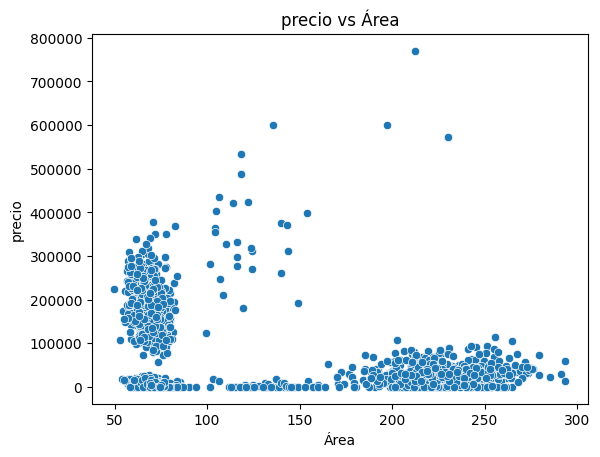

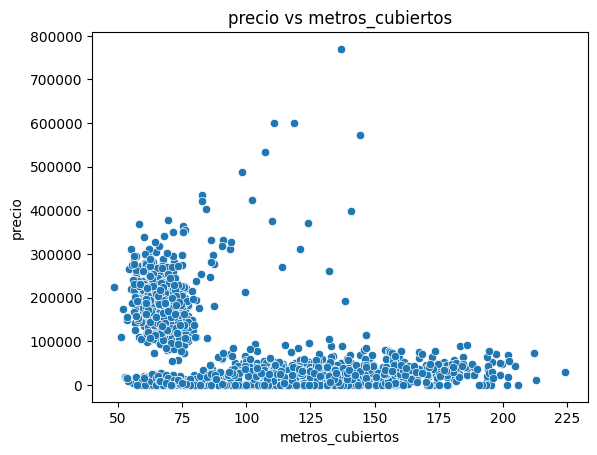

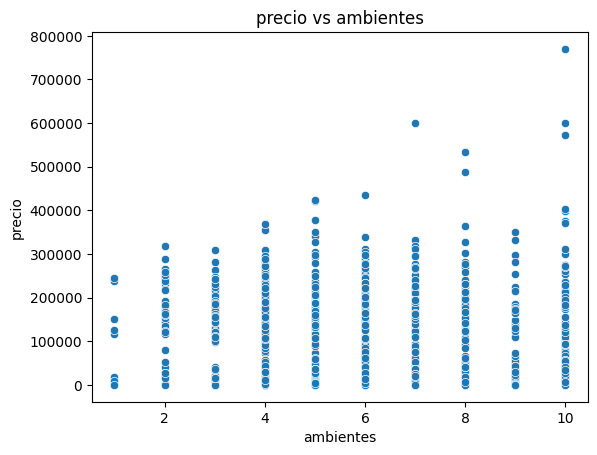

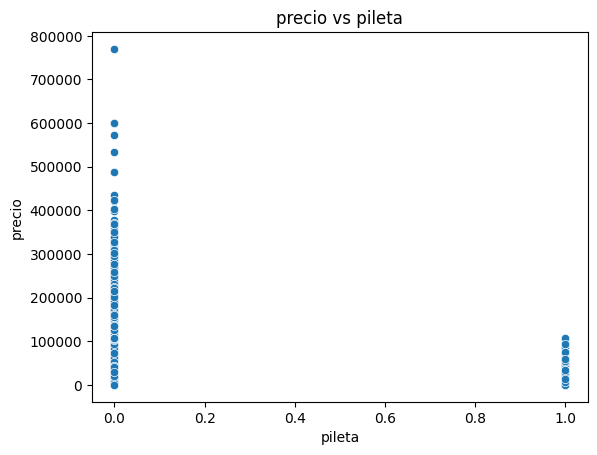

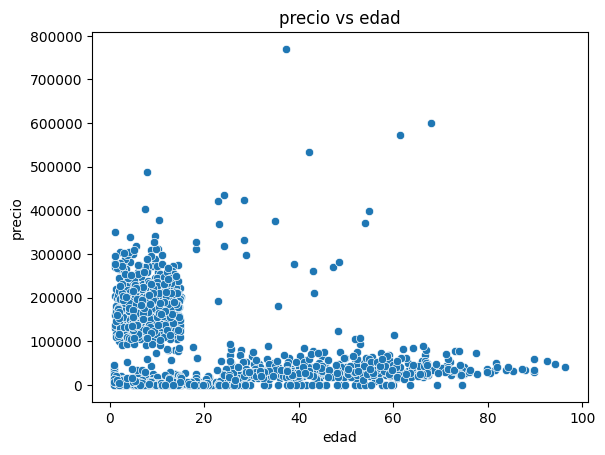

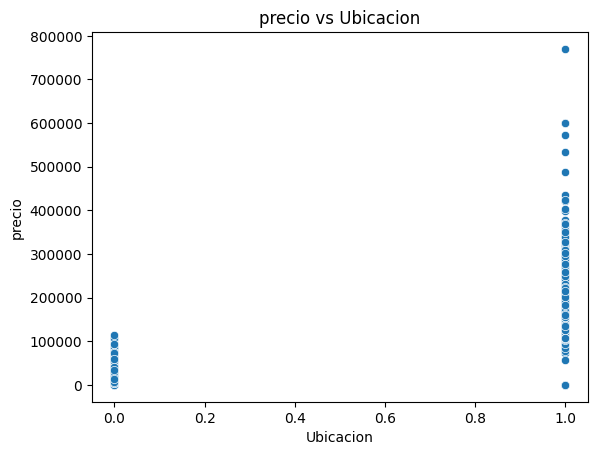

In [447]:
for col in dev.select_dtypes(include=['number']).columns:
    if col != 'precio':
        sns.scatterplot(x=dev[col], y=dev['precio'])
        plt.title(f'precio vs {col}')
        plt.show()

CAMBIAR
Relaciones importantes:
- Precio vs Area/Metro cubiertos:
Cuanto mas terreno --> mas alto el precio

- Precio vs ambientes:
Con mas ambientes aumenta el precio pero hay gran dispersion

Otras:
- Precio vs edad:
Tendencia poco clara y mucho ruido
- Latitud y longitud:
No se puede encontrar ninguna relacion


Con las relaciones importantes podremos entrenar a nuestro modelo para que logre predir correctamente. Las otras no aportan mucho para nuestro modelo (por el momento).

1.3

Separo dataset (80% train - 20% validation)

In [448]:
dev_shuffled = dev.sample(frac=1, random_state=42) 

Creo otra variable para dev, para no cambiar memoria de dev (variable original)

Uso random_state para que siempre se mezcle igual y comparar resultados

In [449]:
total_filas = dev_shuffled.shape[0]
q_filas_train = int(0.8*total_filas)
train_set = dev_shuffled[:q_filas_train]
validation_set = dev_shuffled[q_filas_train:]

train_set.to_csv("../data/casas_train.csv", index=False)
validation_set.to_csv("../data/casas_validation.csv", index=False)

Normalizacion de variables
--> Quiero poder comparar las columnas numericas, en la misma escala.
--> Precio (target) y variables categoricas, lo dejo sin normalizar. Pisos tambien (lo voy a eliminar)
--> Normalizo: Área, metros_cubiertos, ambientes, lat, lon, edad

In [450]:
train = pd.read_csv("../data/casas_train.csv")
validation = pd.read_csv("../data/casas_validation.csv")

In [451]:
min_y_max_variables = {}
for col in train.select_dtypes(include=['number']).columns:
	if col == "pileta" or col == "precio" or col == "pisos":
		continue
	min_y_max_variables[col] = (train[col].min(), train[col].max())


Consigo minimo y maximo de cada columna numerica para poder normalizarlas.
--> Formula de normalizacion a usar = (x - min) / (max - min)

In [452]:
for parte in [train,validation]:
	for col in parte.select_dtypes(include=['number']).columns:
		if col == "pileta" or col == "precio" or col == "Ubicacion":
			continue
		min_col,max_col = min_y_max_variables[col]
		parte[col] = (parte[col] - min_col) / (max_col - min_col) #modifica el dataframe



Normalizo en memoria (no cambio csv) --> Quiero mantener dataset original

Visualizacion de variables normalizadas:

In [453]:
train.sample(5)
validation.sample(5)

,precio,tipo,Área,metros_cubiertos,ambientes,pileta,edad,Ubicacion
177,58.431279,depto,0.079489,0.107889,0.888889,0,0.089399,0
10,33551.967841,casa,0.730504,0.519696,1.000000,1,0.382077,0
218,258188.439223,depto,0.036162,0.048273,0.444444,0,0.096714,1
249,14742.910244,casa,0.817359,0.604877,0.888889,0,0.625603,0
273,179970.582576,depto,0.075781,0.095807,0.666667,0,0.138442,1
